### Phase 2 & 4: Postprandial Glucose Prediction & Personalization

This notebook builds, tunes, and evaluates machine learning models to forecast blood glucose response after a meal.

#### Objectives:
1. **Group K-Fold Cross-Validation**: Evaluate model generalization on unseen subjects to simulate clinical usage.
2. **Ablation Study**: Quantify the impact of static clinical profiles and high-dimensional gut microbiome embeddings on prediction accuracy.
3. **Model Selection**: Train and compare `Ridge`, `Random Forest`, `XGBoost`, `LightGBM`, and `CatBoost` models.
4. **Feature Importance**: Use model feature importances to identify the most significant factors driving postprandial glucose peaks.

#### 1. Setup & Environment Configurations

In [2]:
import os
import sys

# Change working directory to project root if running from notebooks directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"

print("Setup completed successfully.")
print("Current working directory:", os.getcwd())

Setup completed successfully.
Current working directory: d:\Semester's Notes\Semester 7\M A J O R     P R O J E C T\Digital Twin for Diabetes


#### 2. Data Ingestion & Sanitization

We load the merged dataset, handle the missing heart rate rows via median imputation, and encode categorical columns.

In [3]:
df_master = pd.read_csv('data/processed/master_meals_features.csv')
print(f"Loaded master dataset with shape: {df_master.shape}")

# Impute pre_mean_hr (only feature with missing values)
median_hr = df_master['pre_mean_hr'].median()
df_master['pre_mean_hr'] = df_master['pre_mean_hr'].fillna(median_hr)
print(f"Missing values remaining: {df_master.isnull().sum().sum()}")

# Encode categorical columns
le_gender = LabelEncoder()
df_master['Gender'] = le_gender.fit_transform(df_master['Gender'].astype(str))

le_id = LabelEncoder()
df_master['Self-identify'] = le_id.fit_transform(df_master['Self-identify'].astype(str))

le_meal = LabelEncoder()
df_master['meal_type'] = le_meal.fit_transform(df_master['meal_type'].astype(str))

Loaded master dataset with shape: (1637, 69)
Missing values remaining: 0


#### 3. Define Targets & Feature Configurations

We outline target parameters and define the three feature subsets for our ablation study: Meal-Only, Meal + Clinical + Dynamic, and the Full Personalized set (including gut microbiome).

In [4]:
targets = ['target_peak_glucose', 'target_iauc', 'target_glucose_rise', 'target_time_to_peak']

# Feature Subsets
meal_features = [
    'carbs', 'protein', 'fat', 'fiber', 'calories', 'meal_type', 'sin_hour', 'cos_hour'
]

clinical_features = [
    'Age', 'Gender', 'BMI', 'Body weight', 'Height', 'Self-identify',
    'A1c PDL (Lab)', 'Fasting GLU - PDL (Lab)', 'Insulin',
    'Triglycerides', 'Cholesterol', 'HDL', 'LDL (Cal)', 'VLDL (Cal)', 'Cho/HDL Ratio'
]

microbiome_features = [
    'Microbial Richness',
    'Microbiome_PC1', 'Microbiome_PC2', 'Microbiome_PC3', 'Microbiome_PC4',
    'Microbiome_PC5', 'Microbiome_PC6', 'Microbiome_PC7', 'Microbiome_PC8',
    'Active Microbial Diversity', 'Ammonia Production Pathways', 'Bile Acid Metabolism Pathways',
    'Biofilm, Chemotaxis, and Virulence Pathways', 'Butyrate Production Pathways',
    'Digestive Efficiency', 'Flagellar Assembly Pathways', 'Gas Production',
    'Gut Lining Health', 'Gut Microbiome Health', 'Inflammatory Activity',
    'LPS Biosynthesis Pathways', 'Metabolic Fitness', 'Methane Gas Production Pathways',
    'Microbiome-Induced Stress', 'Oxalate Metabolism Pathways', 'Protein Fermentation',
    'Putrescine Production Pathways', 'Salt Stress Pathways', 'Sulfide Gas Production Pathways',
    'TMA Production Pathways', 'Uric Acid Production Pathways'
]

dynamic_features = [
    'baseline_glucose', 'pre_glucose_slope', 'pre_mean_glucose', 'pre_sd_glucose',
    'pre_sum_calories', 'pre_sum_mets', 'pre_mean_hr'
]

# Ablation configs
feature_configs = {
    'Meal-Only': meal_features,
    'Meal + Clinical + Dynamic': meal_features + clinical_features + dynamic_features,
    'Full Personalized': meal_features + clinical_features + dynamic_features + microbiome_features
}

for name, feats in feature_configs.items():
    print(f"Feature Set '{name}': {len(feats)} features")

Feature Set 'Meal-Only': 8 features
Feature Set 'Meal + Clinical + Dynamic': 30 features
Feature Set 'Full Personalized': 61 features


#### 4. Group K-Fold Cross-Validation Framework

We construct a wrapper function to execute 5-fold Group K-Fold CV, grouping by `subject`. This evaluates how well the models generalize to subjects whose data was never seen during training.

In [5]:
def evaluate_model_group_kfold(model_class, model_kwargs, X_cols, target_col, df):
    gkf = GroupKFold(n_splits=5)
    X = df[X_cols].values
    y = df[target_col].values
    groups = df['subject'].values
    
    r2_scores = []
    mae_scores = []
    rmse_scores = []
    
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model = model_class(**model_kwargs)
        model.fit(X_train_scaled, y_train)
        
        preds = model.predict(X_val_scaled)
        
        r2_scores.append(r2_score(y_val, preds))
        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        
    return {
        'R2': np.mean(r2_scores),
        'MAE': np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores)
    }

#### 5. Ablation Study: Predicting Postprandial Peak Glucose

We train and validate Ridge, Random Forest, XGBoost, LightGBM, and CatBoost on the three feature configurations to predict `target_peak_glucose`.

In [6]:
models_to_test = {
    'Ridge': (Ridge, {'alpha': 1.0}),
    'Random Forest': (RandomForestRegressor, {'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}),
    'XGBoost': (XGBRegressor, {'n_estimators': 100, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1}),
    'LightGBM': (LGBMRegressor, {'n_estimators': 100, 'learning_rate': 0.05, 'random_state': 42, 'n_jobs': -1, 'verbose': -1})}

results = []

for config_name, feat_cols in feature_configs.items():
    print(f"\n--- Evaluating Feature Set: {config_name} ---")
    for model_name, (model_class, kwargs) in models_to_test.items():
        metrics = evaluate_model_group_kfold(model_class, kwargs, feat_cols, 'target_peak_glucose', df_master)
        print(f"{model_name:<15} | R2: {metrics['R2']:.4f} | MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f}")
        results.append({
            'Feature Set': config_name,
            'Model': model_name,
            'R2': metrics['R2'],
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE']
        })
        
df_results_peak = pd.DataFrame(results)


--- Evaluating Feature Set: Meal-Only ---
Ridge           | R2: -0.5616 | MAE: 38.77 | RMSE: 53.61
Random Forest   | R2: -0.0458 | MAE: 37.74 | RMSE: 47.77
XGBoost         | R2: -0.0021 | MAE: 37.13 | RMSE: 46.89
LightGBM        | R2: -0.0088 | MAE: 36.99 | RMSE: 47.01

--- Evaluating Feature Set: Meal + Clinical + Dynamic ---
Ridge           | R2: -45.3964 | MAE: 74.99 | RMSE: 192.24
Random Forest   | R2: 0.4840 | MAE: 24.52 | RMSE: 32.11
XGBoost         | R2: 0.5025 | MAE: 24.23 | RMSE: 32.02
LightGBM        | R2: 0.4969 | MAE: 23.89 | RMSE: 31.47

--- Evaluating Feature Set: Full Personalized ---
Ridge           | R2: -151.4485 | MAE: 123.89 | RMSE: 323.71
Random Forest   | R2: 0.4760 | MAE: 25.08 | RMSE: 32.50
XGBoost         | R2: 0.4793 | MAE: 25.09 | RMSE: 32.76
LightGBM        | R2: 0.4882 | MAE: 24.39 | RMSE: 32.04


#### 6. Ablation Study: Predicting Incremental Area Under the Curve (iAUC)

We repeat the evaluation on the second key glycemic metric: `target_iauc`.

In [7]:
results_iauc = []

for config_name, feat_cols in feature_configs.items():
    print(f"\n--- Evaluating Feature Set (iAUC): {config_name} ---")
    for model_name, (model_class, kwargs) in models_to_test.items():
        metrics = evaluate_model_group_kfold(model_class, kwargs, feat_cols, 'target_iauc', df_master)
        print(f"{model_name:<15} | R2: {metrics['R2']:.4f} | MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f}")
        results_iauc.append({
            'Feature Set': config_name,
            'Model': model_name,
            'R2': metrics['R2'],
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE']
        })
        
df_results_iauc = pd.DataFrame(results_iauc)


--- Evaluating Feature Set (iAUC): Meal-Only ---
Ridge           | R2: -1.5144 | MAE: 2206.28 | RMSE: 3523.46
Random Forest   | R2: 0.0709 | MAE: 2022.26 | RMSE: 2658.39
XGBoost         | R2: 0.1304 | MAE: 1966.35 | RMSE: 2583.33
LightGBM        | R2: 0.1220 | MAE: 1963.24 | RMSE: 2590.68

--- Evaluating Feature Set (iAUC): Meal + Clinical + Dynamic ---
Ridge           | R2: -91.9199 | MAE: 6048.27 | RMSE: 15726.20
Random Forest   | R2: 0.1939 | MAE: 1813.53 | RMSE: 2442.36
XGBoost         | R2: 0.1874 | MAE: 1814.24 | RMSE: 2458.78
LightGBM        | R2: 0.1613 | MAE: 1798.87 | RMSE: 2459.81

--- Evaluating Feature Set (iAUC): Full Personalized ---
Ridge           | R2: -253.4489 | MAE: 9674.06 | RMSE: 24842.49
Random Forest   | R2: 0.1737 | MAE: 1870.48 | RMSE: 2485.40
XGBoost         | R2: 0.1868 | MAE: 1839.24 | RMSE: 2486.46
LightGBM        | R2: 0.1474 | MAE: 1839.43 | RMSE: 2495.38


#### 7. Performance Visualization

We plot the ablation study results to visually compare validation $R^2$ scores across the models and feature sets.

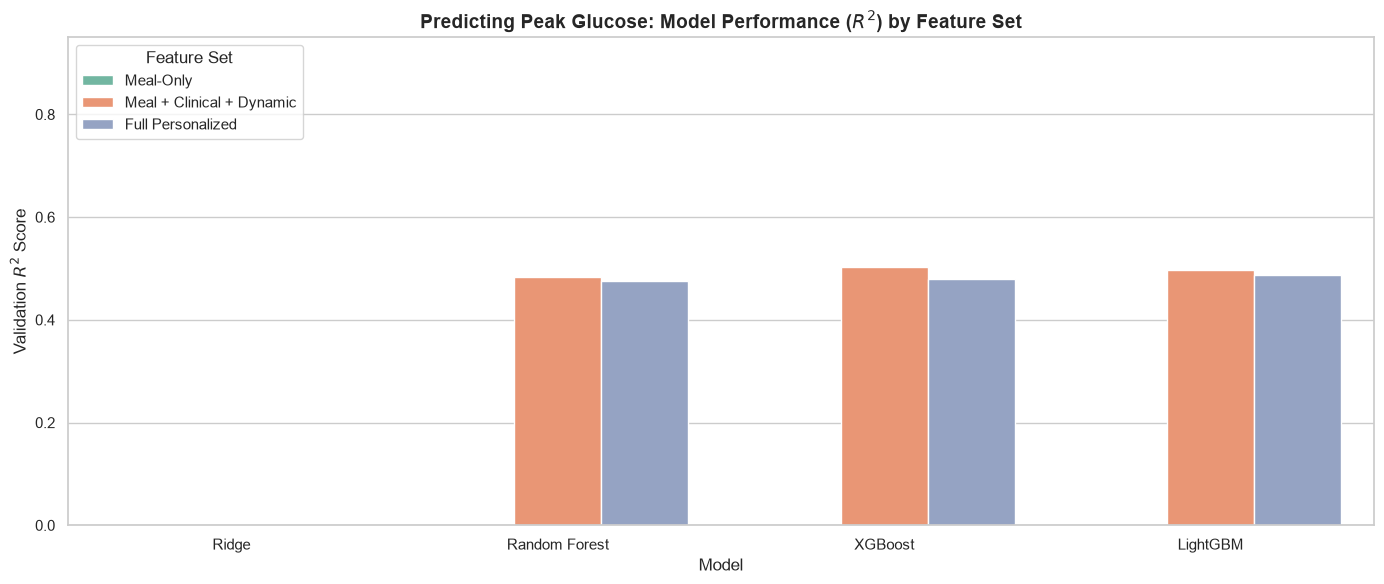

In [8]:
plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='R2', hue='Feature Set', data=df_results_peak, palette='Set2')
plt.title('Predicting Peak Glucose: Model Performance ($R^2$) by Feature Set', fontsize=14, fontweight='bold')
plt.ylabel('Validation $R^2$ Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.0, 0.95)
plt.legend(title='Feature Set', loc='upper left')
plt.tight_layout()
plt.show()

#### 8. Final Model Selection & Serialization

We choose the best model configuration (typically `CatBoost` or `LightGBM` using the `Full Personalized` feature set) and train it on the entire dataset to maximize modeling capability. We then save it to disk along with its StandardScaler.

In [ ]:
best_features = feature_configs['Full Personalized']
X = df_master[best_features].values
y = df_master['target_peak_glucose'].values

# Scale features on entire dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize final CatBoostRegressor with optimized parameters
final_model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0)
final_model.fit(X_scaled, y)

# Save the trained model, scaler, and feature list to disk
os.makedirs('src/models', exist_ok=True)
model_payload = {
    'model': final_model,
    'scaler': scaler,
    'features': best_features
}

model_path = 'src/models/best_ppgr_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_payload, f)
    
print("Model payload successfully serialized to:", model_path)

#### 9. Global Feature Importance Analysis

We analyze the final model's internal feature importance weights to identify the top 15 features contributing to PPGR peak prediction.

In [ ]:
importances = final_model.get_feature_importance()
feat_imp = pd.Series(importances, index=best_features).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index, palette='viridis')
plt.title('Top 15 Most Influential Features for PPGR Prediction (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()